# FTP-IDS — Exploratory Data Analysis

**Project:** FTPGuard: and FTP Intrusion Detection System  
**Data:** session-level features extracted from vsftpd logs (17 features per session)

In [154]:
import pandas as pd
from ftp_ids.core.feature_extractor import FeatureExtractor
from ftp_ids.parsers.vsftpd_parser import VsftpdParser
from ftp_ids.core.session_builder import build_sessions

log_path = '../data/samples/vsftpd.log'

parser = VsftpdParser()
events, failed = [], []
with open(log_path, "r") as f:
    for line in f:
        event = parser.parse_line(line)
        if event: 
            events.append(event) 
        else: 
            failed.append(line)

sessions = build_sessions(events)

fe = FeatureExtractor()
features = fe.extract_batch(sessions)

df = pd.DataFrame(features)

print(f"Parsed {len(events)}/{len(events) + len(failed)} lines, {len(failed)} failed.")
print(f"Successfully extracted features from {len(df)} sessions.")
df.head()

Parsed 9700/9709 lines, 9 failed.
Successfully extracted features from 104 sessions.


,total_events,failed_logins,downloads,uploads,unique_commands,unique_files,night_events,total_bytes,avg_speed,session_duration,fail_ratio,night_ratio,transfer_ratio,bytes_per_file,garbage_cmd_ratio,abrupt_disconnect,is_auth
0,124,0,1,10,15,8,124,3444037.0,534.941818,32.0,0.0,1.0,0.088710,430504.625000,0.0,0,1
1,136,0,1,12,15,10,0,3487511.0,532.996923,46.0,0.0,0.0,0.095588,348751.100000,0.0,0,1
2,148,0,1,14,15,12,0,3500263.0,947.926000,49.0,0.0,0.0,0.101351,291688.583333,0.0,0,1
3,118,0,1,9,15,7,118,3520853.0,561.308000,34.0,0.0,1.0,0.084746,502979.000000,0.0,0,1
4,142,0,1,13,15,11,0,3535249.0,793.707143,56.0,0.0,0.0,0.098592,321386.272727,0.0,0,1


## Overview

In [155]:
rows = []
for s in sessions:
    feats = fe.extract(s)
    rows.append({
        "src_ip": s["src_ip"],
        "user": s.get("user") or "",
        "start_time": s["start_time"],
        "end_time": s["end_time"],
        "end_type": s["end_type"],
        **feats,
    })

df = pd.DataFrame(rows)
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])

print(f"Sessions:          {len(df)}")
print(f"Unique source IPs: {df['src_ip'].nunique()}")
print(f"Unique users:      {df['user'].replace('', '(none)').nunique()}")
print(f"Date range:        {df['start_time'].min()} -> {df['start_time'].max()}")
print()
print("Sessions per user:")

print(df["user"].replace("", "none").value_counts())

Sessions:          104
Unique source IPs: 80
Unique users:      5
Date range:        2026-04-16 05:44:27 -> 2026-06-25 04:53:58

Sessions per user:
user
deploy_user    96
anonymous       4
none            2
fakeuser        1
admin           1
Name: count, dtype: int64


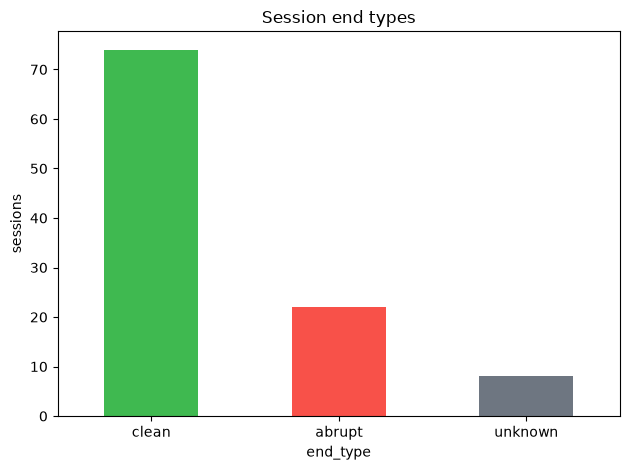

In [156]:
import matplotlib.pyplot as plt

counts = df["end_type"].value_counts()
ax = counts.plot(kind="bar", color=["#3fb950", "#f85149", "#6e7681"])
ax.set_title("Session end types")
ax.set_ylabel("sessions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Behavioural breakdown

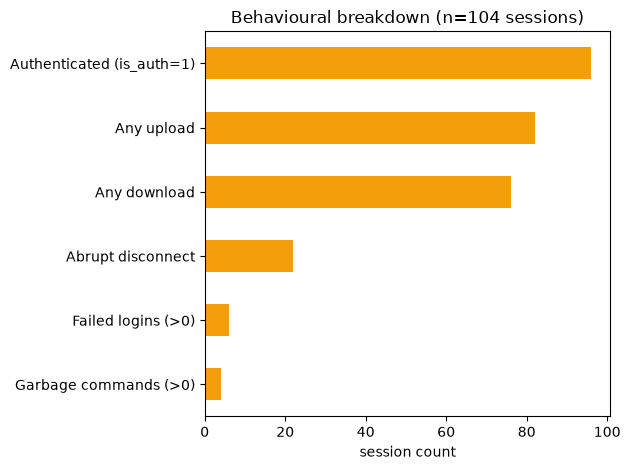

In [157]:
behaviours = {
    "Authenticated (is_auth=1)":   (df["is_auth"] == 1).sum(),
    "Failed logins (>0)":          (df["failed_logins"] > 0).sum(),
    "Garbage commands (>0)":       (df["garbage_cmd_ratio"] > 0).sum(),
    "Abrupt disconnect":           (df["abrupt_disconnect"] == 1).sum(),
    "Any upload":                  (df["uploads"] > 0).sum(),
    "Any download":                (df["downloads"] > 0).sum(),
}
bdf = pd.Series(behaviours).sort_values()

ax = bdf.plot(kind="barh", color="#f59e0b")
ax.set_title(f"Behavioural breakdown (n={len(df)} sessions)")
ax.set_xlabel("session count")
plt.tight_layout()
plt.show()

## 3. Feature distributions

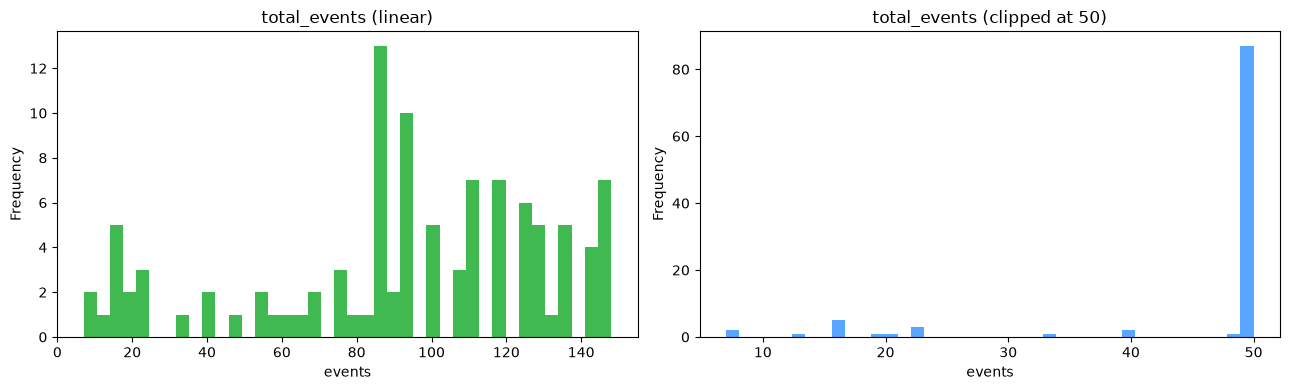

In [158]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["total_events"].plot(kind="hist", bins=40, ax=axes[0], color="#3fb950")
axes[0].set_title("total_events (linear)")
axes[0].set_xlabel("events")

df["total_events"].clip(upper=50).plot(kind="hist", bins=40, ax=axes[1], color="#58a6ff")
axes[1].set_title("total_events (clipped at 50)")
axes[1].set_xlabel("events")

plt.tight_layout()
plt.show()

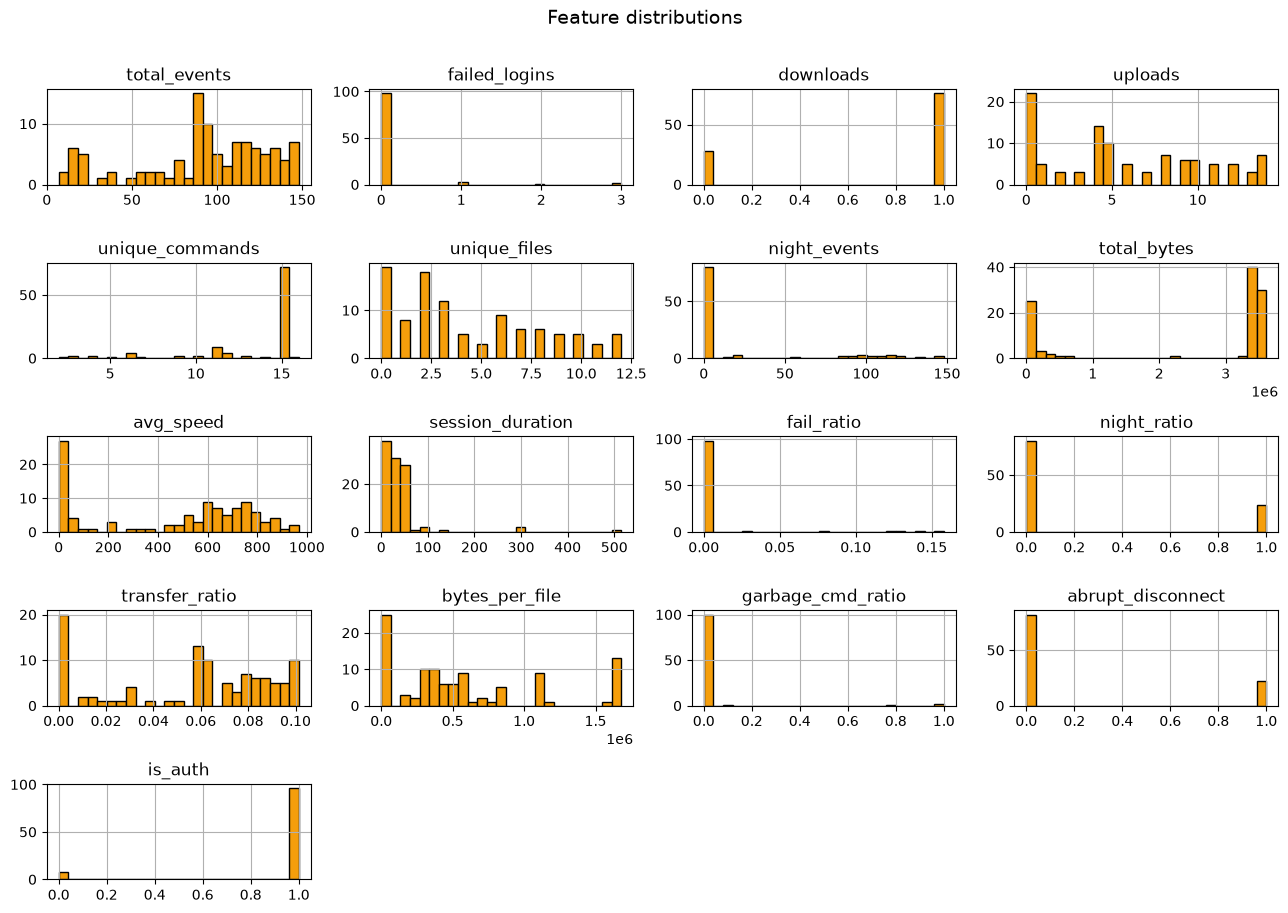

In [159]:
# grid_feats = [
#     "total_events", "failed_logins", "uploads", "downloads",
#     "unique_commands", "unique_files", "session_duration",
#     "garbage_cmd_ratio", "fail_ratio",
# ]
feature_names = [
    "total_events", "failed_logins", "downloads", "uploads",
    "unique_commands", "unique_files", "night_events",
    "total_bytes", "avg_speed", "session_duration",
    "fail_ratio", "night_ratio", "transfer_ratio",
    "bytes_per_file", "garbage_cmd_ratio",
    "abrupt_disconnect", "is_auth"
]

df[feature_names].hist(bins=25, figsize=(13, 9), color="#f59e0b", edgecolor="black")
plt.suptitle("Feature distributions", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 4. Temporal pattern

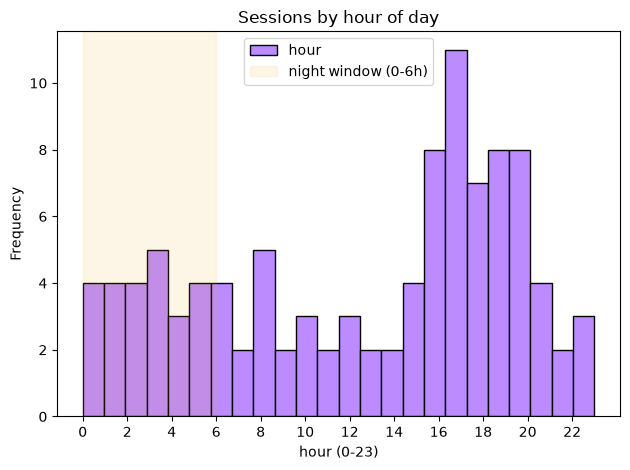

Night sessions (00:00-06:00): 24/104 (23%)


In [160]:
df["hour"] = df["start_time"].dt.hour

ax = df["hour"].plot(kind="hist", bins=24, color="#bc8cff", edgecolor="black")
ax.set_title("Sessions by hour of day")
ax.set_xlabel("hour (0-23)")
ax.set_xticks(range(0, 24, 2))
ax.axvspan(0, 6, color="#f59e0b", alpha=0.1, label="night window (0-6h)")
ax.legend()
plt.tight_layout()
plt.show()

night = (df["hour"] < 6).sum()
print(f"Night sessions (00:00-06:00): {night}/{len(df)} ({100*night/len(df):.0f}%)")

## 5. Feature correlations

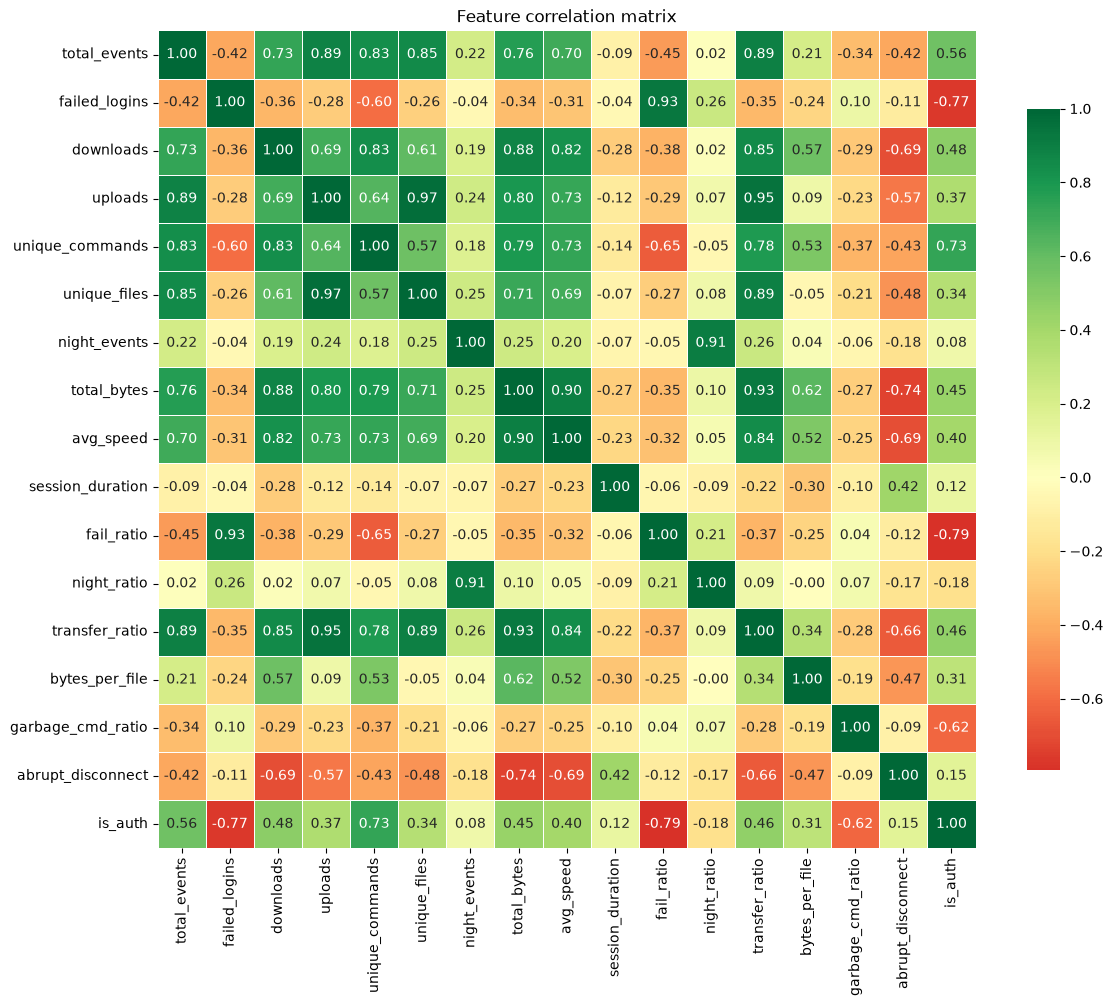

In [161]:
import seaborn as sns

corr = df[feature_names].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## 6. Class balance (heuristic preview)

A session is *probably normal* if it authenticated as the deploy user 
and used only known FTP commands; otherwise *probably hostile*.

Probably normal:  96  (92%)
Probably hostile: 8  (8%)


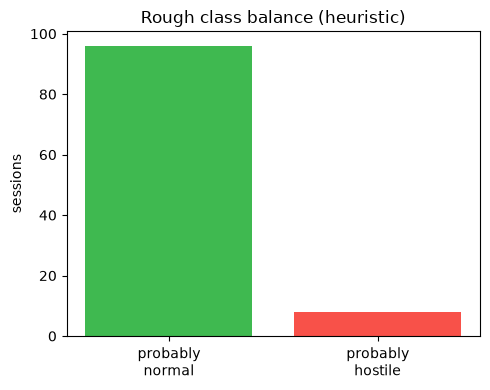

In [162]:
is_deploy = df["user"].str.contains("deploy_user") & (df["is_auth"] == 1)
n_norm = is_deploy.sum()
n_attack = len(df) - n_norm

print(f"Probably normal:  {n_norm}  ({100*n_norm/len(df):.0f}%)")
print(f"Probably hostile: {n_attack}  ({100*n_attack/len(df):.0f}%)")

plt.figure(figsize=(5, 4))
plt.bar(["probably\nnormal", "probably\nhostile"], [n_norm, n_attack],
        color=["#3fb950", "#f85149"])
plt.title("Rough class balance (heuristic)")
plt.ylabel("sessions")
plt.tight_layout()
plt.show()

## 7. Deploy session profile

The pairplot below compares 5 key features against each other for every 
session in the training data. Each dot is one session.

Since the training data consists mainly of legitimate CI/CD deployments, 
we expect a tight, consistent cluster — confirming that deploys follow a 
predictable pattern that Isolation Forest can learn as the "normal" baseline.

The few scattered dots near zero correspond to a small number of attack 
sessions present in the production log.

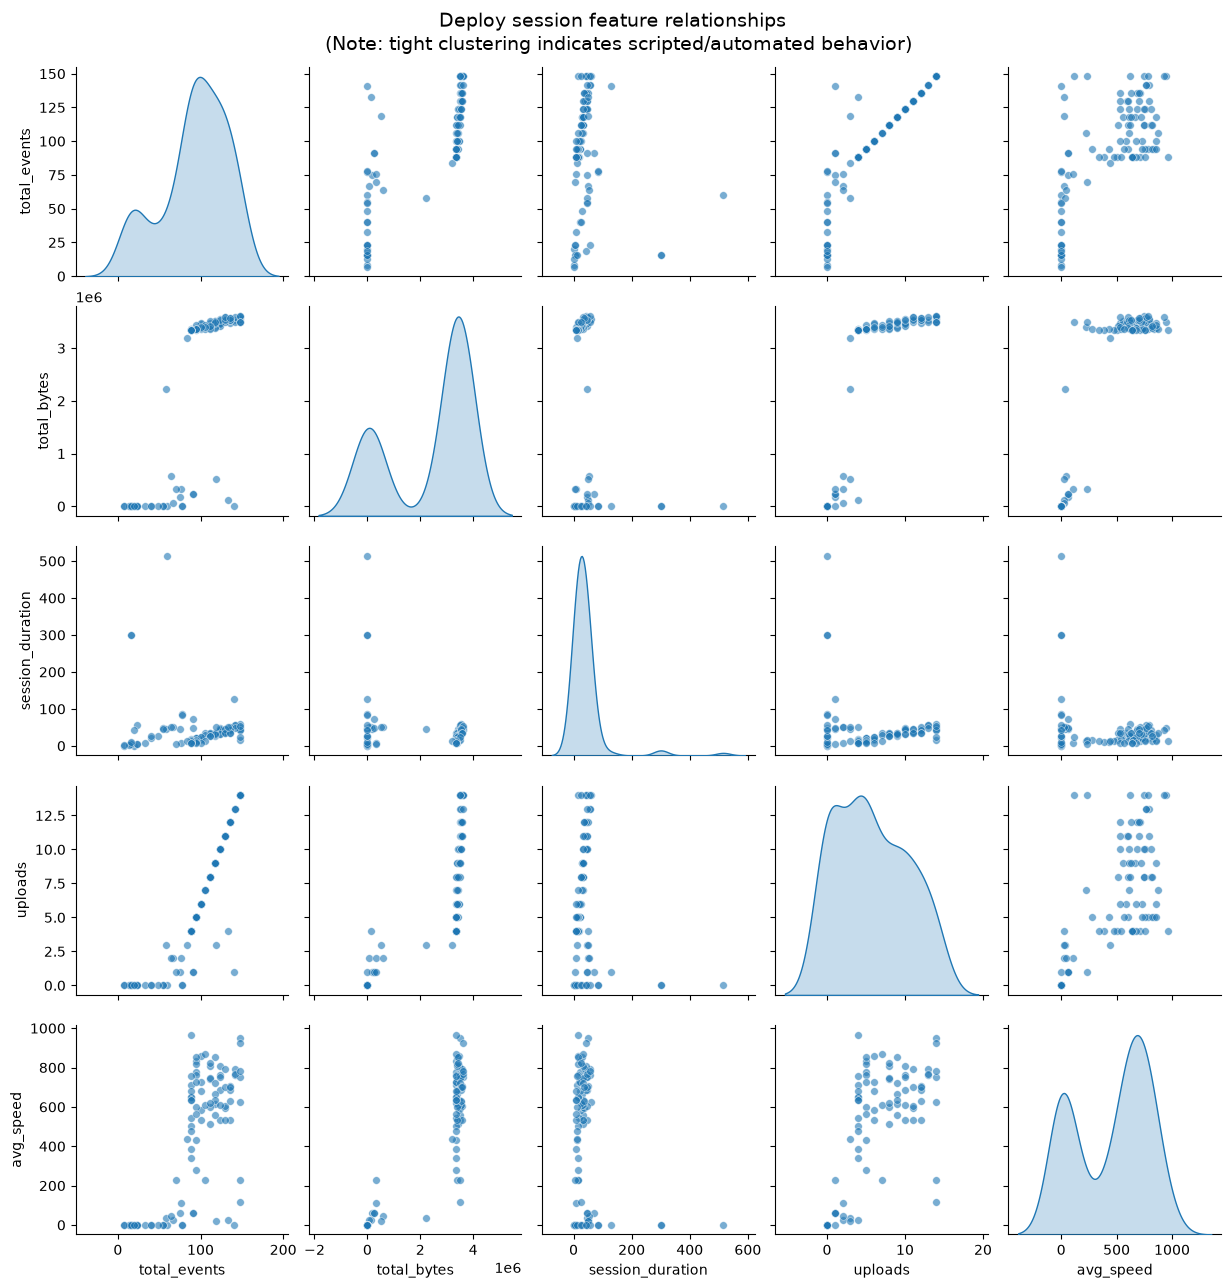

In [163]:
g = sns.pairplot(
    df[['total_events', 'total_bytes', 'session_duration', 'uploads', 'avg_speed']],
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
g.fig.suptitle("Deploy session feature relationships \n (Note: tight clustering indicates scripted/automated behavior)", 
               y=1.03, fontsize=14)
plt.show()

## 8. Summary

In [165]:
night = (df["start_time"].dt.hour < 6).sum()
is_deploy = df["user"].str.contains("deploy_user|dev_user") & (df["is_auth"] == 1)

print(f"Volume:          {len(df)} sessions from {df['src_ip'].nunique()} unique IPs")
print(f"Date range:      {df['start_time'].min().date()} to {df['start_time'].max().date()}")
print(f"Session size:    median {df['total_events'].median():.0f} events")
print(f"Authenticated:   {(df['is_auth']==1).sum()} sessions ({100*(df['is_auth']==1).mean():.0f}%)")
print(f"Garbage cmds:    {(df['garbage_cmd_ratio']>0).sum()} sessions")
print(f"Abrupt disconn:  {(df['abrupt_disconnect']==1).sum()} sessions")
print(f"Failed logins:   {(df['failed_logins']>0).sum()} sessions")
print(f"Night sessions:  {night} ({100*night/len(df):.0f}%)")
print(f"Class balance:   {is_deploy.sum()} normal ({100*is_deploy.mean():.0f}%) / {(~is_deploy).sum()} attack ({100*(~is_deploy).mean():.0f}%)")


deploys = df[is_deploy]
print(f"\n--- Deploy profile ---")
print(f"Total deploys:   {len(deploys)}")
print(f"Uploads/deploy:  {deploys['uploads'].min():.0f}-{deploys['uploads'].max():.0f} files (mean: {deploys['uploads'].mean():.1f})")
print(f"Bytes/deploy:    {deploys['total_bytes'].min()/1e6:.1f}-{deploys['total_bytes'].max()/1e6:.1f} MB (mean: {deploys['total_bytes'].mean()/1e6:.1f} MB)")
print(f"Speed:           {deploys['avg_speed'].min():.0f}-{deploys['avg_speed'].max():.0f} KB/s (mean: {deploys['avg_speed'].mean():.0f} KB/s)")
print(f"Duration:        {deploys['session_duration'].min():.0f}-{deploys['session_duration'].max():.0f}s (mean: {deploys['session_duration'].mean():.0f}s)")
print(f"Clean exits:     {(deploys['end_type']=='clean').sum()}/{len(deploys)}")

Volume:          104 sessions from 80 unique IPs
Date range:      2026-04-16 to 2026-06-25
Session size:    median 94 events
Authenticated:   96 sessions (92%)
Garbage cmds:    4 sessions
Abrupt disconn:  22 sessions
Failed logins:   6 sessions
Night sessions:  24 (23%)
Class balance:   96 normal (92%) / 8 attack (8%)

--- Deploy profile ---
Total deploys:   96
Uploads/deploy:  0-14 files (mean: 6.2)
Bytes/deploy:    0.0-3.6 MB (mean: 2.6 MB)
Speed:           0-967 KB/s (mean: 490 KB/s)
Duration:        4-515s (mean: 42s)
Clean exits:     72/96
